In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("deep")

In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/ML Projects/Project07_Sales_Forecasting_Using_ML/E-commerce_Sales_Data(2014-17).csv", encoding="cp1252")

In [ ]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [ ]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
df.shape

(9994, 21)

In [ ]:
df["Segment"].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


In [ ]:
# Data Cleaning & Standardization
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=["Row ID", "Ship Date", "Ship Mode", "Customer Name", "Customer ID", "Country", "City", "State", "Postal Code", "Product Name"], inplace=True)

In [ ]:
df.columns= df.columns.str.lower().str.replace(" ","_")

In [ ]:
df.columns

Index(['order_id', 'order_date', 'segment', 'region', 'product_id', 'category',
       'sub-category', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [ ]:
#Feature Engineering

In [ ]:
df["order_date"]=pd.to_datetime(df["order_date"]) #converting in object to date-time
df["months"] = df["order_date"].dt.month_name() #Month feature
df["years"] = df["order_date"].dt.year #Year feature
df["quarter"] = df["order_date"].dt.quarter #Year

In [ ]:
df["discount_pct"] = df["discount"] * 100

In [ ]:
#EDA

In [ ]:
#Sales Distribution

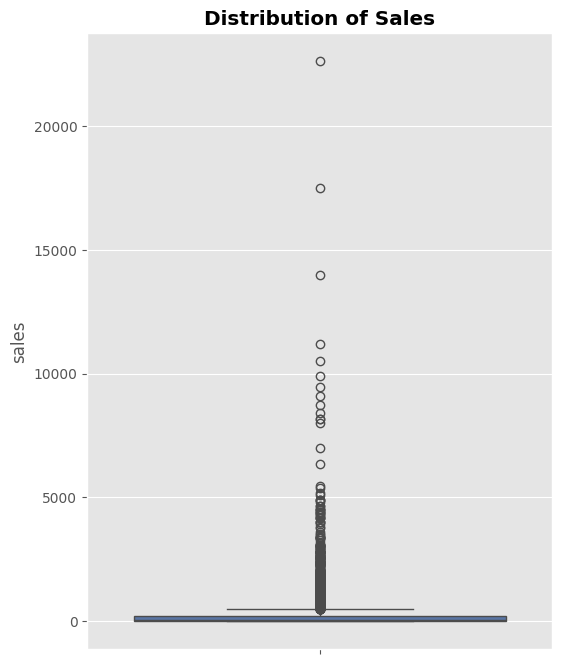

In [ ]:
plt.figure(figsize=(6, 8))

sns.boxplot(data = df, y="sales")
plt.title("Distribution of Sales",fontweight="bold")

plt.show()

#### Insight
- Sales are heavily right-skewed — most orders sit below $500, with a long tail of high-value outliers reaching above $20,000.

In [ ]:
# Time Series Analysis

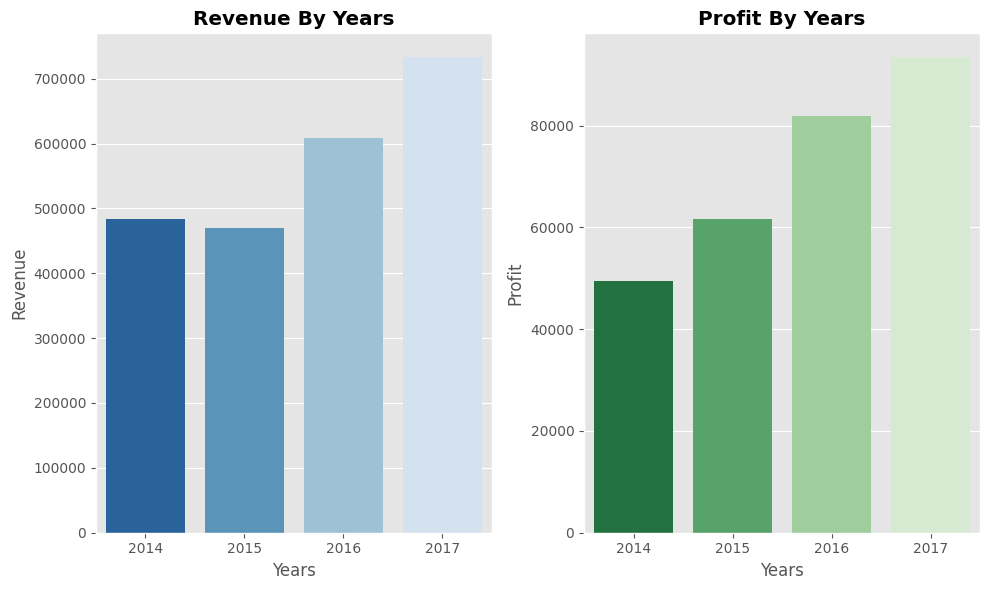

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
year_revenue = df.groupby("years")["sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = year_revenue, x="years", y="sales", palette ="Blues_r")
plt.title("Revenue By Years",fontweight="bold")
plt.xlabel("Years")
plt.ylabel("Revenue")

plt.subplot(1,2,2)
year_profit = df.groupby("years")["profit"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = year_profit, x="years", y="profit",palette ="Greens_r")
plt.title("Profit By Years",fontweight="bold")
plt.xlabel("Years")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

#### Insight
- Revenue and profit grew every year from 2014 to 2017, with the steepest jump between 2016 and 2017.

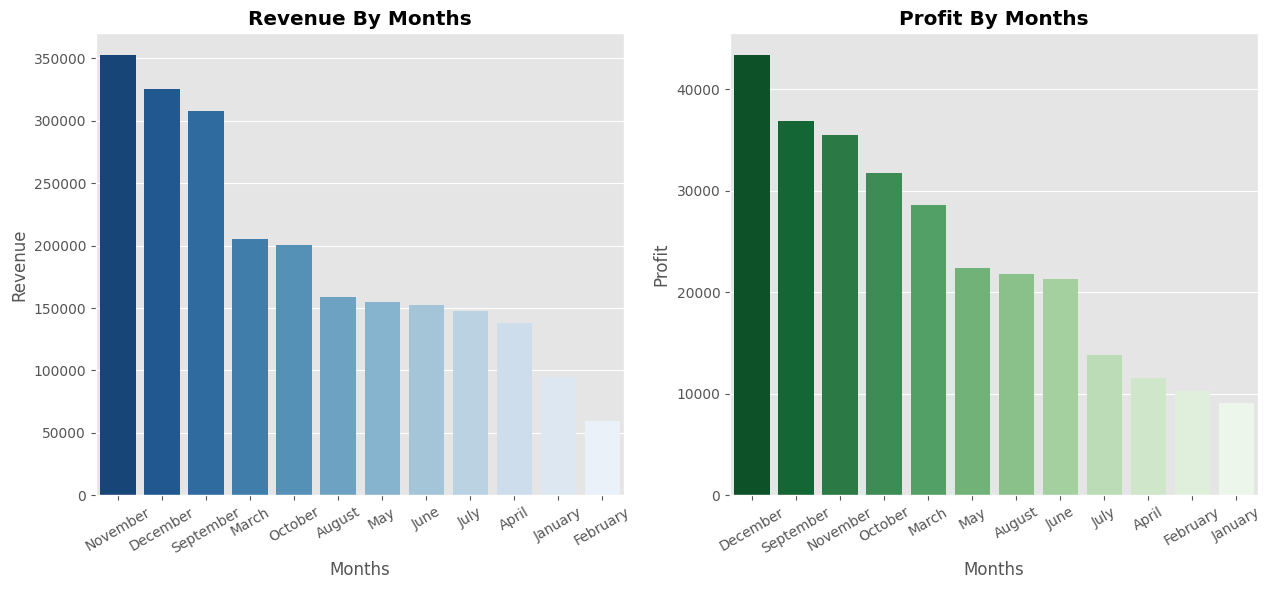

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
month_revenue = df.groupby("months")["sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = month_revenue, x="months", y="sales", palette ="Blues_r")
plt.title("Revenue By Months",fontweight="bold")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.xticks(rotation = 30)

plt.subplot(1,2,2)
month_profit = df.groupby("months")["profit"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = month_profit, x="months", y="profit",palette ="Greens_r")
plt.title("Profit By Months",fontweight="bold")
plt.xlabel("Months")
plt.ylabel("Profit")
plt.xticks(rotation = 30)

plt.show()

#### Insight
- November, December, and September are consistently the strongest months for revenue and profit; January and February are the weakest.

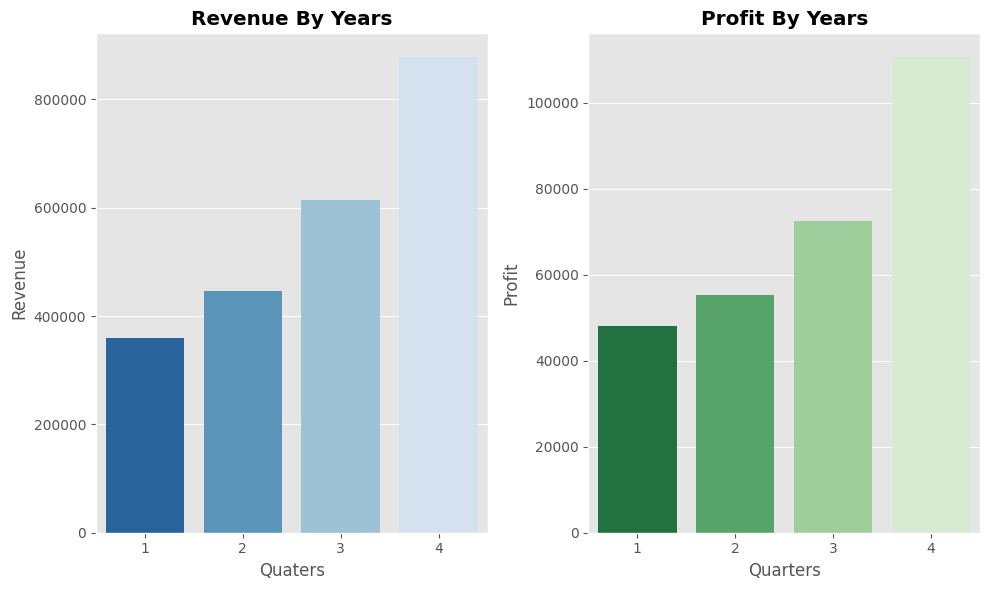

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
quarter_revenue = df.groupby("quarter")["sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = quarter_revenue, x="quarter", y="sales", palette ="Blues_r")
plt.title("Quarterly Revenue",fontweight="bold")
plt.xlabel("Quaters")
plt.ylabel("Revenue")

plt.subplot(1,2,2)
quarter_profit = df.groupby("quarter")["profit"].sum().sort_values( ascending = False).reset_index()

sns.barplot(data = quarter_profit, x="quarter", y="profit",palette ="Greens_r")
plt.title("Quarterly Profit",fontweight="bold")
plt.xlabel("Quarters")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

#### Insight
- Revenue and profit rise steadily through the year and peak sharply in Q4, more than double Q1's totals — reinforcing the monthly seasonality above.

In [ ]:
#Categorical Analysis

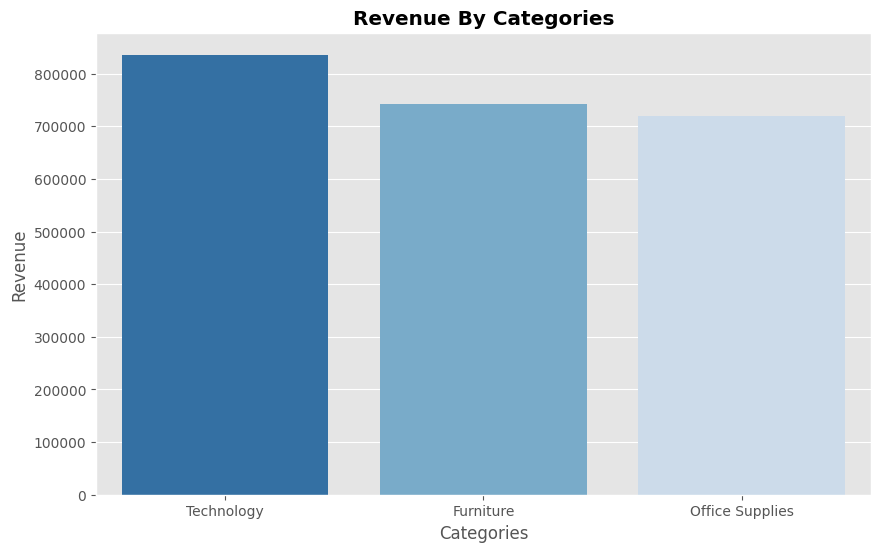

In [ ]:
plt.figure(figsize=(10,6))

categorical_revenue = df.groupby("category")["sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = categorical_revenue, x="category", y="sales",palette ="Blues_r")
plt.title("Revenue By Categories",fontweight="bold")
plt.xlabel("Categories")
plt.ylabel("Revenue")

plt.show()

#### Insight
- Technology leads revenue, narrowly ahead of Furniture and Office Supplies — all three contribute meaningfully, with no single category dominating.

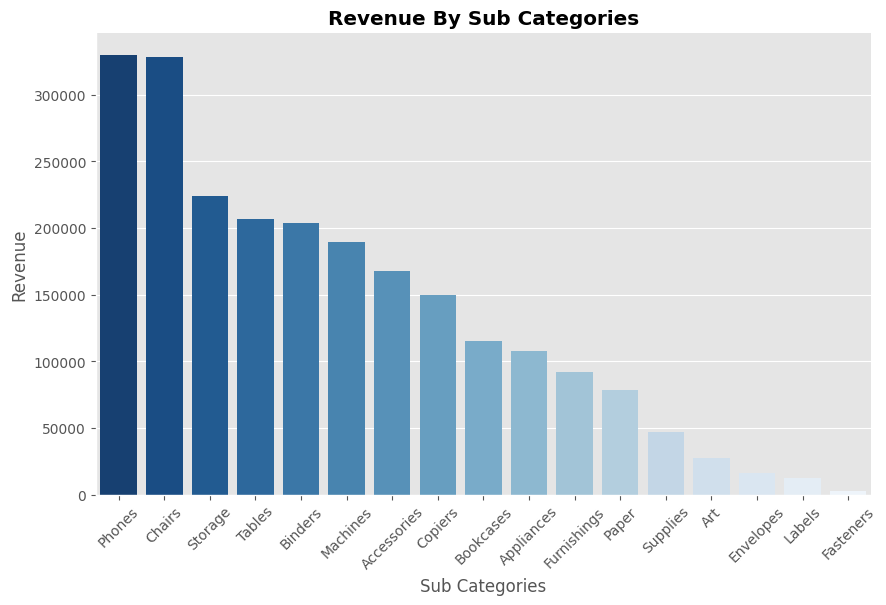

In [ ]:
plt.figure(figsize=(10,6))

categorical_revenue = df.groupby("sub-category")["sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = categorical_revenue, x="sub-category", y="sales",palette ="Blues_r")
plt.title("Revenue By Sub Categories",fontweight="bold")
plt.xlabel("Sub Categories")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
sns.despine()
plt.show()

#### Insight
- Phones and Chairs are the clear revenue drivers, more than triple lower sub-categories like Bookcases or Appliances. Low-cost supplies (Fasteners, Labels, Envelopes) contribute the least despite high order volume.

In [ ]:
#Regional Analysis

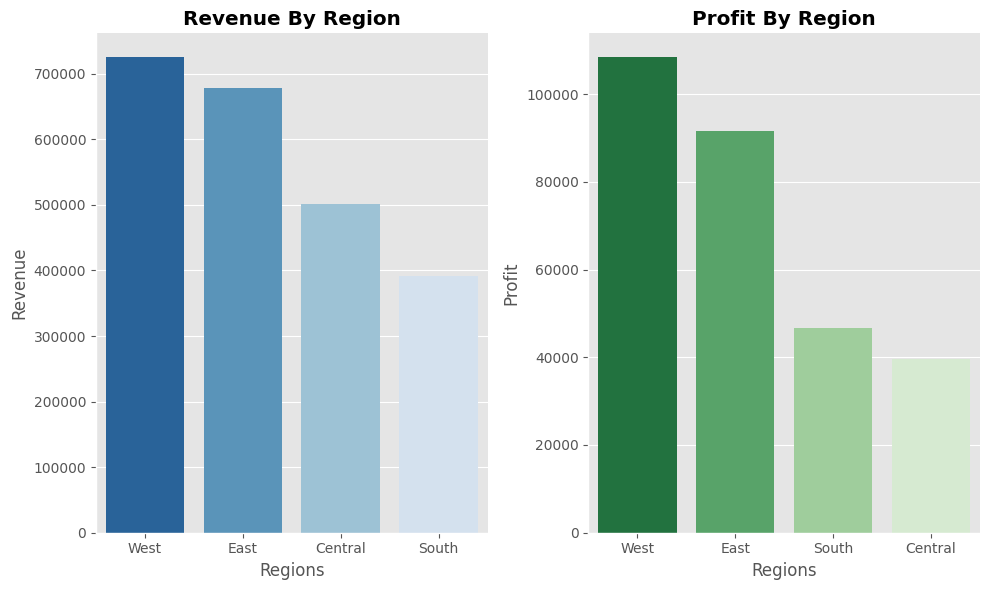

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
regional_revenue = df.groupby("region")["sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = regional_revenue, x="region", y="sales", palette = "Blues_r")
plt.title("Revenue By Region",fontweight="bold")
plt.xlabel("Regions")
plt.ylabel("Revenue")

plt.subplot(1,2,2)
regional_profit = df.groupby("region")["profit"].sum().sort_values(ascending = False).reset_index()

sns.barplot(data = regional_profit, x="region", y="profit", palette = "Greens_r")
plt.title("Profit By Region",fontweight="bold")
plt.xlabel("Regions")
plt.ylabel("Profit")

plt.tight_layout()
sns.despine()
plt.show()

#### Insight
- West leads on both revenue and profit, followed by East. Central outranks South on revenue but falls behind it on profit — a sign of a regional discounting or cost-efficiency issue worth investigating.

In [ ]:
#Discount Analysis

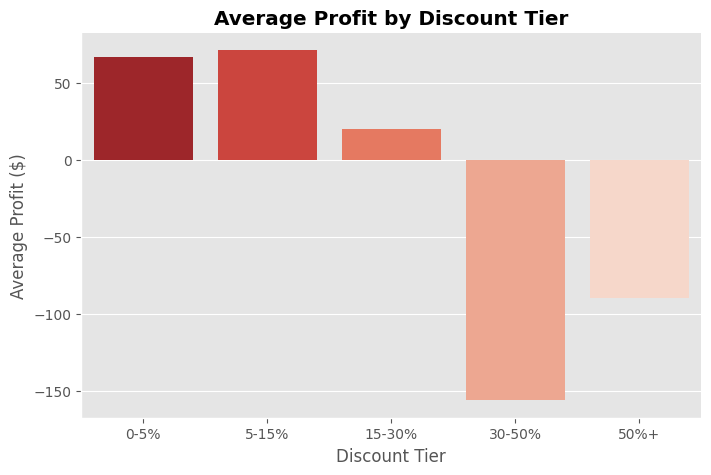

In [ ]:
df["discount_bucket"] = pd.cut(
    df["discount"],
    bins=[0, 0.05, 0.15, 0.30, 0.50, 1.0],
    labels=["0-5%", "5-15%", "15-30%", "30-50%", "50%+"],
    include_lowest=True,
)
discount_profit = df.groupby("discount_bucket")["profit"].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(data=discount_profit, x="discount_bucket", y="profit", palette="Reds_r")
plt.title("Average Profit by Discount Tier", fontweight="bold")
plt.xlabel("Discount Tier")
plt.ylabel("Average Profit ($)")
sns.despine()

plt.show()

#### Insight
- Average profit stays positive only up to a 30% discount; beyond that it turns negative, with the 30–50% tier averaging roughly -$155 per order.

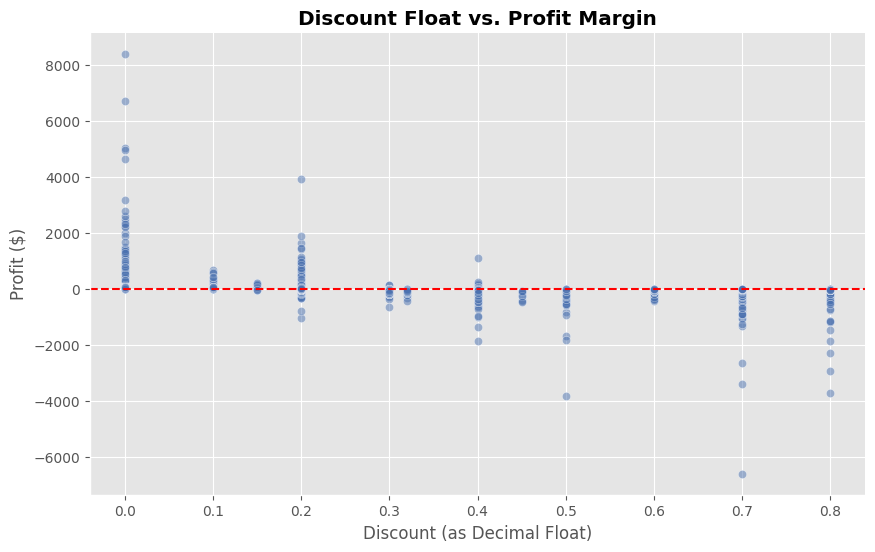

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="discount", y="profit", alpha=0.5,palette="Blues_d")
plt.axhline(0, color="red", linestyle="--")

plt.title("Discount Float vs. Profit Margin", fontweight="bold")
plt.xlabel("Discount (as Decimal Float)", fontsize=12)
plt.ylabel("Profit ($)")
sns.despine()

plt.show()

#### Insight
- Confirms the discount-tier pattern at the transaction level — profit clusters highest near 0% discount and grows increasingly negative past 50%, with some losses exceeding -$6,000.

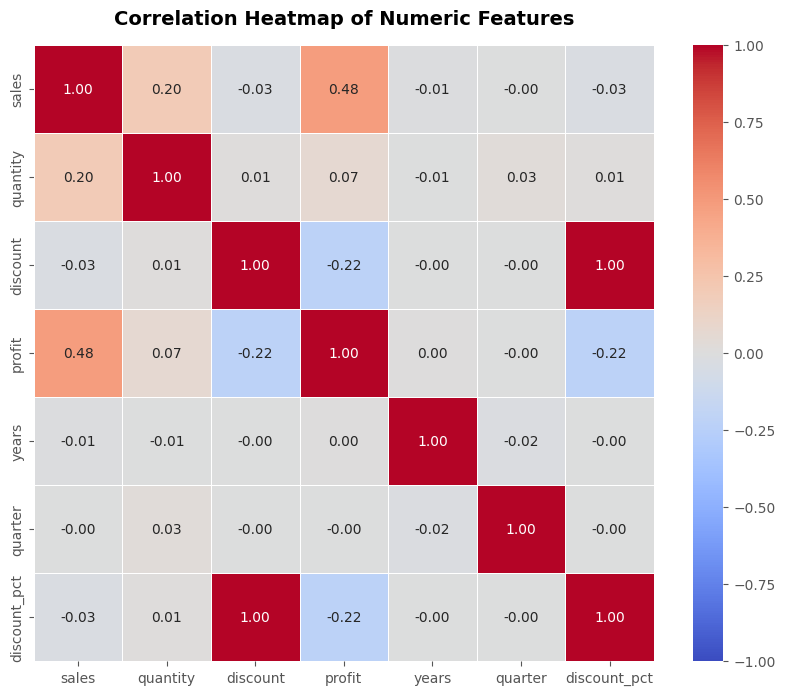

In [ ]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=14, pad=15, fontweight="bold")
plt.show()

#### Insight
- Sales and profit are moderately correlated (0.48) — revenue growth doesn't translate to profit one-for-one. Discount is negatively correlated with profit (-0.22), statistically confirming the discount analysis above.

## EDA Summary & Recommendations

### Key Takeaways
- Revenue and profit follow a clear, repeatable seasonal pattern, peaking in Q4 (especially Nov-Dec).
- Technology and a handful of high-ticket sub-categories (Phones, Chairs) drive a disproportionate share of revenue.
- Central region underperforms on profit relative to its revenue rank.
- Discounting beyond ~30% is associated with negative average profit.

### Recommendation
- Use month/quarter seasonality as the primary predictive signal in the forecasting model (Project 08).
- Track profitability at the sub-category level, not just category level, given Technology's revenue concentration.
- Audit Central region's discounting and cost structure to close the profit gap relative to South.
- Cap or condition discounts above 30% on order value/category rather than applying them broadly.